# 06 — Text Clustering & Topic Modeling (Track B)

**Owner**: Person A

Use TF-IDF vectorization on enriched occupation texts (descriptions + tasks + 
work activities + technology) to discover text-based occupation clusters.
Compare with the skills-based clusters from notebook 04 (Track A).

### Input files
- `../data/processed/occupation_texts.csv` (API-enriched text, from notebook 04)
- `../data/processed/cluster_labels.csv` (Track A cluster assignments)

### Output files
- `../outputs/tfidf_pca_scatter.png`
- `../outputs/text_vs_skill_clusters.png`
- `../outputs/topic_modeling_results.png`

In [1]:
# === Track B: Text Clustering (TF-IDF + Topic Modeling) ===
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF
from sklearn.metrics import silhouette_score
from src.theme import CLUSTER_COLORS, CMAP_SEQUENTIAL, apply_font
apply_font()

texts_df = pd.read_csv('../data/processed/occupation_texts.csv')
cluster_labels = pd.read_csv('../data/processed/cluster_labels.csv')

texts_df = texts_df.merge(
    cluster_labels[['O*NET-SOC Code', 'cluster_name']],
    left_on='onet_code', right_on='O*NET-SOC Code', how='left'
)

print(f"Loaded {len(texts_df)} occupations, avg text length: {texts_df['full_text'].str.len().mean():.0f} chars")
print("Sample text (first 300 chars):")
print(texts_df.iloc[0]['full_text'][:300])

Loaded 20 occupations, avg text length: 1417 chars
Sample text (first 300 chars):
Plan, direct, or coordinate operations and functionalities of facilities and buildings. May include surrounding grounds or multiple facilities of an organization's campus. Key tasks: Monitor the facility to ensure that it remains safe, secure, and well-maintained.. Oversee the maintenance and repair


In [2]:
# === Step 1: TF-IDF Vectorization ===
tfidf = TfidfVectorizer(
    max_features=200,
    stop_words='english',
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,              # appear in at least 2 docs
    max_df=0.9             # ignore terms in >90% of docs
)

tfidf_matrix = tfidf.fit_transform(texts_df['full_text'])
print(f"TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Top 20 features: {tfidf.get_feature_names_out()[:20].tolist()}")

# === Step 2: PCA on TF-IDF for visualization ===
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
tfidf_2d = svd.fit_transform(tfidf_matrix)
print(f"\nSVD explained variance: {svd.explained_variance_ratio_.sum():.3f}")

# === Step 3: K-Means on TF-IDF (k=3 to match Track A) ===
km_text = KMeans(n_clusters=3, n_init=20, random_state=42)
text_labels = km_text.fit_predict(tfidf_matrix)
sil = silhouette_score(tfidf_matrix, text_labels)
print(f"Text clustering silhouette score: {sil:.3f}")

# === Step 4: Compare Track A vs Track B ===
texts_df['text_cluster'] = text_labels
comparison = pd.crosstab(
    texts_df['cluster_name'],
    texts_df['text_cluster'],
    margins=True
)
print(f"\n=== Track A (skills) vs Track B (text) cross-tab ===")
print(comparison)

TF-IDF matrix: (20, 200)
Top 20 features: ['3d', 'accounting', 'accounting software', 'actions', 'activities communicating', 'activities getting', 'aided', 'aided design', 'analytical', 'analytical scientific', 'assemble', 'assemble install', 'autocad', 'autocad civil', 'autodesk', 'autodesk autocad', 'base', 'base user', 'blueprints', 'building']

SVD explained variance: 0.188
Text clustering silhouette score: 0.103

=== Track A (skills) vs Track B (text) cross-tab ===
text_cluster            0  1  2  All
cluster_name                        
Entry Level/Operators   4  0  6   10
Management/Engineering  0  4  0    4
Skilled Trades          3  2  1    6
All                     7  6  7   20


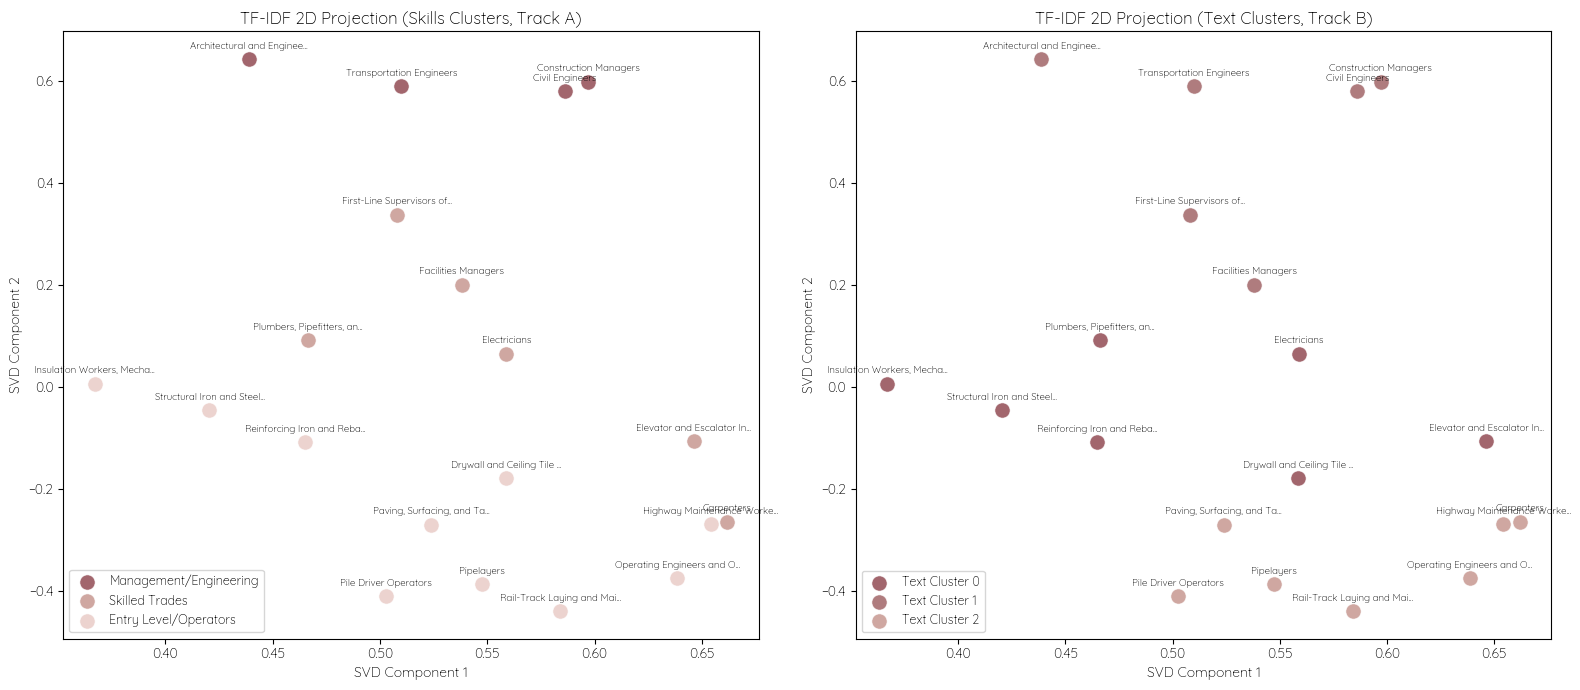

Saved text_vs_skill_clusters.png


In [3]:
# === Step 5: Visualization -- Track A vs Track B scatter ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

cluster_colors = CLUSTER_COLORS
for cname, color in cluster_colors.items():
    mask = texts_df['cluster_name'] == cname
    ax1.scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1],
                c=color, s=120, alpha=0.8, edgecolors='white',
                linewidth=0.5, label=cname)
for i, row in texts_df.iterrows():
    short = row['title'][:25] + '...' if len(row['title']) > 25 else row['title']
    ax1.annotate(short, (tfidf_2d[i, 0], tfidf_2d[i, 1]),
                 fontsize=7, ha='center', va='bottom', xytext=(0, 6),
                 textcoords='offset points')
ax1.set_title('TF-IDF 2D Projection (Skills Clusters, Track A)', fontweight='bold')
ax1.set_xlabel('SVD Component 1')
ax1.set_ylabel('SVD Component 2')
ax1.legend(fontsize=9)

text_colors = ['#8B4049', '#9B5B5E', '#C4918A']
for cl in range(3):
    mask = texts_df['text_cluster'] == cl
    ax2.scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1],
                c=text_colors[cl], s=120, alpha=0.8, edgecolors='white',
                linewidth=0.5, label=f'Text Cluster {cl}')
for i, row in texts_df.iterrows():
    short = row['title'][:25] + '...' if len(row['title']) > 25 else row['title']
    ax2.annotate(short, (tfidf_2d[i, 0], tfidf_2d[i, 1]),
                 fontsize=7, ha='center', va='bottom', xytext=(0, 6),
                 textcoords='offset points')
ax2.set_title('TF-IDF 2D Projection (Text Clusters, Track B)', fontweight='bold')
ax2.set_xlabel('SVD Component 1')
ax2.set_ylabel('SVD Component 2')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/text_vs_skill_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved text_vs_skill_clusters.png")


NMF Topics (top 10 terms each):
Topic 0: equipment,software microsoft,microsoft,office,machine,machines,drive,repair,operating,operate
Topic 1: construction,design,project,autodesk,standards,direct,engineering,plan,development,compliance
Topic 2: using,steel,materials,install,blueprints,metal,insulation,tools,pipe,rods
Topic Distribution by Track A Cluster:
dominant_topic          0  1  2  All
cluster_name                        
Entry Level/Operators   6  0  4   10
Management/Engineering  0  4  0    4
Skilled Trades          1  2  3    6
All                     7  6  7   20


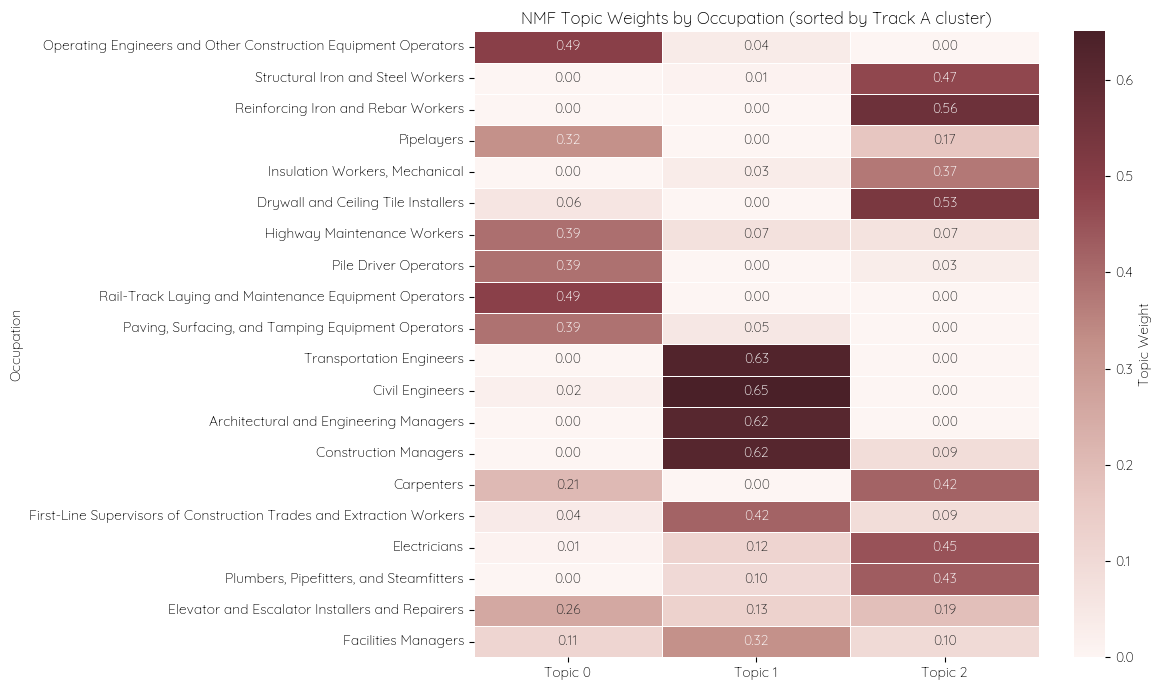

Saved topic_modeling_results.png


In [4]:
# === Step 6: Topic Modeling with NMF ===
from sklearn.decomposition import NMF

nmf = NMF(n_components=3, random_state=42, max_iter=500)
W = nmf.fit_transform(tfidf_matrix)
H = nmf.components_

feature_names = tfidf.get_feature_names_out()

print("NMF Topics (top 10 terms each):")
topic_labels = []
for i, topic in enumerate(H):
    top_terms = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topic {i}: {chr(44).join(top_terms)}")
    topic_labels.append(top_terms[:3])

texts_df['dominant_topic'] = W.argmax(axis=1)

print("Topic Distribution by Track A Cluster:")
print(pd.crosstab(texts_df['cluster_name'], texts_df['dominant_topic'], margins=True))

# === Step 7: Topic visualization -- heatmap ===
fig, ax = plt.subplots(figsize=(12, 7))

heatmap_data = pd.DataFrame(W, columns=[f'Topic {i}' for i in range(3)])
heatmap_data['Occupation'] = texts_df['title'].values
heatmap_data['Cluster (Track A)'] = texts_df['cluster_name'].values
heatmap_data = heatmap_data.sort_values('Cluster (Track A)')
heatmap_data = heatmap_data.set_index('Occupation')

sns.heatmap(
    heatmap_data.drop(columns='Cluster (Track A)'),
    annot=True, fmt='.2f', cmap=CMAP_SEQUENTIAL, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Topic Weight'}
)
ax.set_title('NMF Topic Weights by Occupation (sorted by Track A cluster)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/topic_modeling_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved topic_modeling_results.png")


In [5]:
# === Step 8: Summary & Save ===

# Name the topics based on top terms
topic_names = {
    0: 'Equipment Operations',
    1: 'Engineering & Management', 
    2: 'Installation & Fabrication'
}
texts_df['topic_name'] = texts_df['dominant_topic'].map(topic_names)

# Agreement rate between Track A and Track B
# Map text clusters to best-matching Track A clusters
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(texts_df['cluster_name'], texts_df['text_cluster'])
ari_topic = adjusted_rand_score(texts_df['cluster_name'], texts_df['dominant_topic'])

print("=== Track B Summary ===")
print(f"TF-IDF features: {tfidf_matrix.shape[1]}")
print(f"Text K-Means silhouette: {sil:.3f} (vs Track A: 0.315)")
print(f"Adjusted Rand Index (K-Means vs Track A): {ari:.3f}")
print(f"Adjusted Rand Index (NMF topics vs Track A): {ari_topic:.3f}")

print(f"\nNMF Topic Assignments:")
for _, row in texts_df[['title', 'cluster_name', 'topic_name']].iterrows():
    match = '✔' if (
        (row['cluster_name'] == 'Management/Engineering' and row['topic_name'] == 'Engineering & Management') or
        (row['cluster_name'] == 'Entry Level/Operators' and row['topic_name'] == 'Equipment Operations') or
        (row['cluster_name'] == 'Skilled Trades' and row['topic_name'] == 'Installation & Fabrication')
    ) else '✘'
    print(f"  {match} {row['title'][:45]:45s} | {row['cluster_name']:25s} | {row['topic_name']}")

# Save
texts_df.to_csv('../data/processed/text_clustering_results.csv', index=False)
print(f"\nSaved text_clustering_results.csv")

=== Track B Summary ===
TF-IDF features: 200
Text K-Means silhouette: 0.103 (vs Track A: 0.315)
Adjusted Rand Index (K-Means vs Track A): 0.269
Adjusted Rand Index (NMF topics vs Track A): 0.269

NMF Topic Assignments:
  ✘ Facilities Managers                           | Skilled Trades            | Engineering & Management
  ✔ Construction Managers                         | Management/Engineering    | Engineering & Management
  ✔ Architectural and Engineering Managers        | Management/Engineering    | Engineering & Management
  ✔ Civil Engineers                               | Management/Engineering    | Engineering & Management
  ✔ Transportation Engineers                      | Management/Engineering    | Engineering & Management
  ✘ First-Line Supervisors of Construction Trades | Skilled Trades            | Engineering & Management
  ✔ Carpenters                                    | Skilled Trades            | Installation & Fabrication
  ✔ Paving, Surfacing, and Tamping Equipment